# Missing Data Imputation 🚢
**Dataset:** Titanic Survival  
**Goal:** Demonstrate and compare various techniques for handling missing numerical and categorical data using both `pandas` (for intuition) and `scikit-learn` (for production pipelines).

In [1142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [1143]:
df=pd.read_csv('Titanic-Dataset.csv')

In [1144]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",NaN,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1145]:
df=df.drop(columns=['PassengerId', 'Name', 'Ticket','Cabin'])[['Age', 'Fare', 'Survived']]

In [1146]:
X_train, X_test, y_train, y_test=train_test_split(df.drop(columns=['Survived']), df['Survived'], test_size=0.2, random_state=42)

In [1147]:
X_train.isnull().mean()*100

Age     19.662921
Fare     3.089888
dtype: float64

## 1. Mean & Median Imputation
**When to use:** When data is Missing Completely at Random (MCAR) and the missing data is less than 5% of the total dataset. 
* Use **Mean** when the data is normally distributed.
* Use **Median** when the data contains outliers.

In [1148]:
#Compute mean and median for Imputation
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [1149]:
X_train_mm=X_train.copy()

X_train_mm['Age_median']=X_train_mm['Age'].fillna(median_age)
X_train_mm['Age_mean']=X_train_mm['Age'].fillna(mean_age)

X_train_mm['Fare_median']=X_train_mm['Fare'].fillna(median_fare)
X_train_mm['Fare_mean']=X_train_mm['Fare'].fillna(mean_fare)

In [1150]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age variance after median imputation: ', X_train_mm['Age_median'].var())
print('Age variance after mean imputation: ', X_train_mm['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare variance after median imputation: ', X_train_mm['Fare_median'].var())
print('Fare variance after mean imputation: ', X_train_mm['Fare_mean'].var())

Original Age variable variance:  210.2517072477435
Age variance after median imputation:  169.20731007048155
Age variance after mean imputation:  168.85193366872227
Original Fare variable variance:  2689.346521142139
Fare variance after median imputation:  2615.8163083073273
Fare variance after mean imputation:  2606.131860853634


In [1151]:
def plot_distribution(original, transformed1, transformed2, labels, title):
    fig, ax = plt.subplots()

    # Original
    original.plot(kind='kde', ax=ax, label='Original')

    # Transformed versions
    transformed1.plot(kind='kde', ax=ax, label=labels[0])
    transformed2.plot(kind='kde', ax=ax, label=labels[1])

    # Styling
    plt.legend()
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Density")

    plt.show()

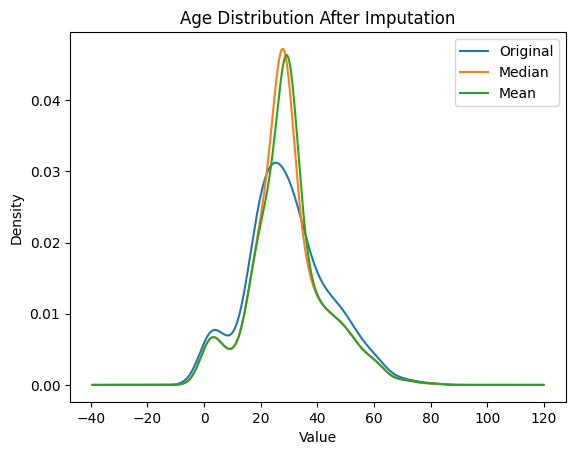

In [1152]:
plot_distribution(
    X_train['Age'],
    X_train_mm['Age_median'],
    X_train_mm['Age_mean'],
    ['Median', 'Mean'],
    "Age Distribution After Imputation"
)

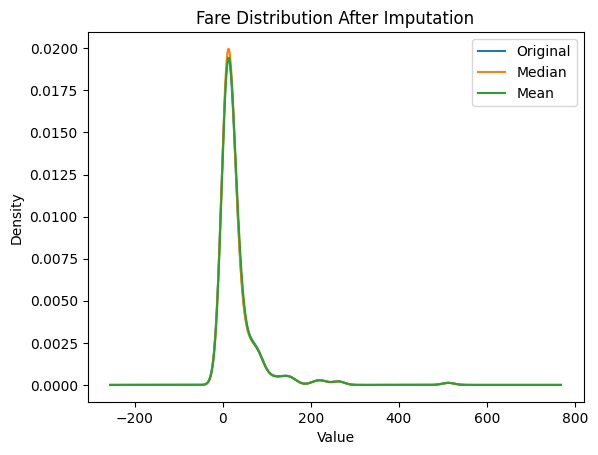

In [1153]:
plot_distribution(
    X_train['Fare'],
    X_train_mm['Fare_median'],
    X_train_mm['Fare_mean'],
    ['Median', 'Mean'],
    "Fare Distribution After Imputation"
)

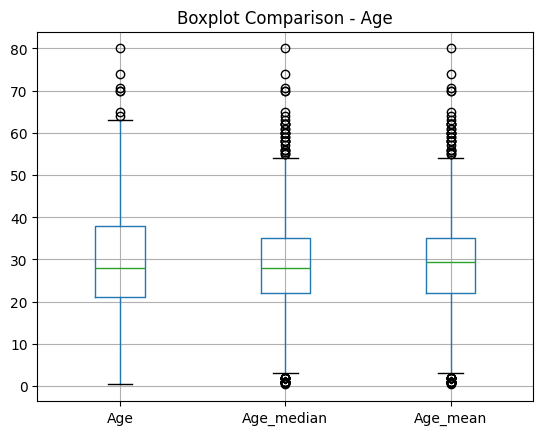

In [1154]:
X_train_mm[['Age', 'Age_median', 'Age_mean']].boxplot()
plt.title("Boxplot Comparison - Age")
plt.show()

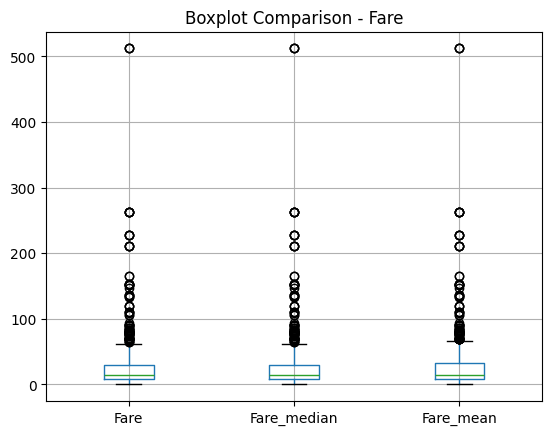

In [1155]:
X_train_mm[['Fare', 'Fare_median', 'Fare_mean']].boxplot()
plt.title("Boxplot Comparison - Fare")
plt.show()

In [1156]:
imputer_median=SimpleImputer(strategy='median')
imputer_mean=SimpleImputer(strategy='mean')

In [1157]:
trf_mm=ColumnTransformer([
    ('imputer_age', imputer_median, ['Age']),
    ('imputer_fare', imputer_mean, ['Fare'])
], remainder='passthrough')

In [1158]:
#Fit
trf_mm.fit(X_train)

,transformers,"[('imputer_age', ...), ('imputer_fare', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [1159]:
trf_mm.named_transformers_['imputer_age'].statistics_

array([28.])

In [1160]:
trf_mm.named_transformers_['imputer_fare'].statistics_

array([32.22531928])

In [1161]:
#Transform
X_train_mm_trans=trf_mm.transform(X_train)
X_test_mm_trans=trf_mm.transform(X_test)

#Conver to DataFrame
X_train_mm_trans=pd.DataFrame(X_train_mm_trans, columns=['Age', 'Fare'], index=X_train.index)
X_test_mm_trans=pd.DataFrame(X_test_mm_trans, columns=['Age', 'Fare'], index=X_test.index)    

In [1162]:
X_train_mm_trans.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


## 2. Arbitrary Value Imputation
**When to use:** When data is NOT missing at random. We filling missing values with arbitrary numbers (like 99 or -1) that are far away from the normal observations

In [1163]:
X_train_arb=X_train.copy()

X_train_arb['Age_99']=X_train_arb['Age'].fillna(99)
X_train_arb['Age_minus1']=X_train_arb['Age'].fillna(-1)

X_train_arb['Fare_95']=X_train_arb['Fare'].fillna(95)
X_train_arb['Fare_minus1']=X_train_arb['Fare'].fillna(-1)

In [1164]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age variance after imputation of 99: ', X_train_arb['Age_99'].var())
print('Age variance after imputation of -1: ', X_train_arb['Age_minus1'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare variance after imputation of 95: ', X_train_arb['Fare_95'].var())
print('Fare variance after imputation of -1: ', X_train_arb['Fare_minus1'].var())

Original Age variable variance:  210.2517072477435
Age variance after imputation of 99:  932.9665366701432
Age variance after imputation of -1:  315.9955036260055
Original Fare variable variance:  2689.346521142139
Fare variance after imputation of 95:  2724.297498344779
Fare variance after imputation of -1:  2639.2343386614716


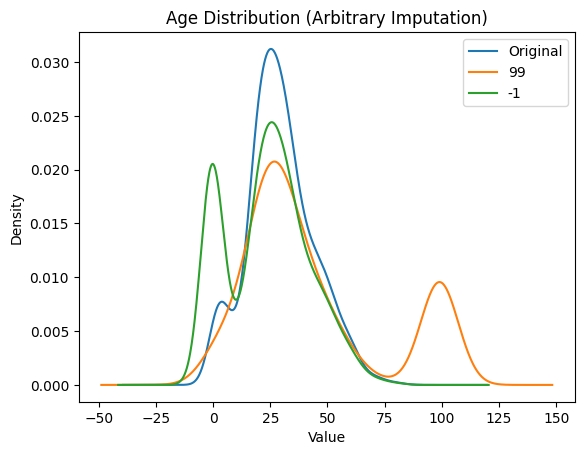

In [1165]:
plot_distribution(
    X_train['Age'],
    X_train_arb['Age_99'],
    X_train_arb['Age_minus1'],
    ['99', '-1'],
    "Age Distribution (Arbitrary Imputation)"
)

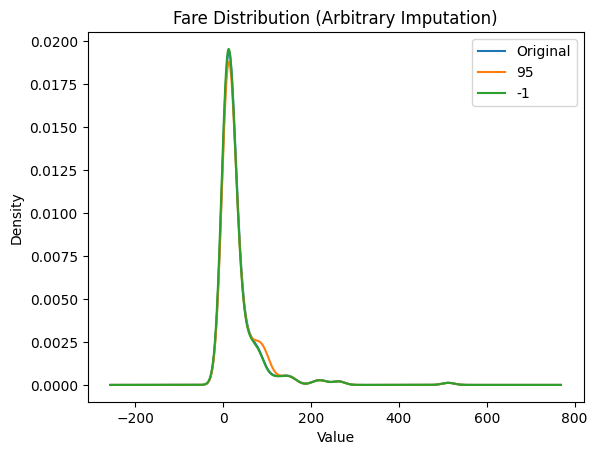

In [1166]:
plot_distribution(
    X_train['Fare'],
    X_train_arb['Fare_95'],
    X_train_arb['Fare_minus1'],
    ['95', '-1'],
    "Fare Distribution (Arbitrary Imputation)"
)

In [1167]:
imputer_99=SimpleImputer(strategy='constant', fill_value=99)
imputer_95=SimpleImputer(strategy='constant', fill_value=95)

In [1168]:
trf_arb=ColumnTransformer([
    ('imputer_age', imputer_99, ['Age']),
    ('imputer_fare', imputer_95, ['Fare'])
], remainder='passthrough')

In [1169]:
trf_arb.fit(X_train)

,transformers,"[('imputer_age', ...), ('imputer_fare', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [1170]:
trf_arb.named_transformers_['imputer_age'].statistics_

array([99.])

In [1171]:
trf_arb.named_transformers_['imputer_fare'].statistics_

array([95.])

In [1172]:
#Transform
X_train_arb_trans=trf_arb.transform(X_train)
X_test_arb_trans=trf_arb.transform(X_test)

X_train_arb_trans=pd.DataFrame(X_train_arb_trans, columns=['Age', 'Fare'], index=X_train.index)
X_test_arb_trans=pd.DataFrame(X_test_arb_trans, columns=['Age', 'Fare'], index=X_test.index)

In [1173]:
X_train_arb_trans.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


## 3. End of Distribution (EOD) Imputation
**When to use:** Similar to arbitrary imputation, this is used when data is missing non-randomly. Instead of guessing a random number like 99, we mathematically calculate a value at the far tail of the distribution (Mean + 3 * Standard Deviation) to flag the missingness for our models.

In [1174]:
mean_age=X_train['Age'].mean()
std_age=X_train['Age'].std()

mean_fare=X_train['Fare'].mean()
std_fare=X_train['Fare'].std()

extreme_value_age=mean_age+3*std_age
extreme_value_fare=mean_fare+3*std_fare

In [1175]:
X_train_eod=X_train.copy()

X_train_eod['Age_eod']=X_train_eod['Age'].fillna(extreme_value_age)
X_train_eod['Fare_eod']=X_train_eod['Fare'].fillna(extreme_value_fare)

In [1176]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age variance after end of distribution imputation: ', X_train_eod['Age_eod'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare variance after end of distribution imputation: ', X_train_eod['Fare_eod'].var())

Original Age variable variance:  210.2517072477435
Age variance after end of distribution imputation:  468.1862516249037
Original Fare variable variance:  2689.346521142139
Fare variance after end of distribution imputation:  3331.9226479205104


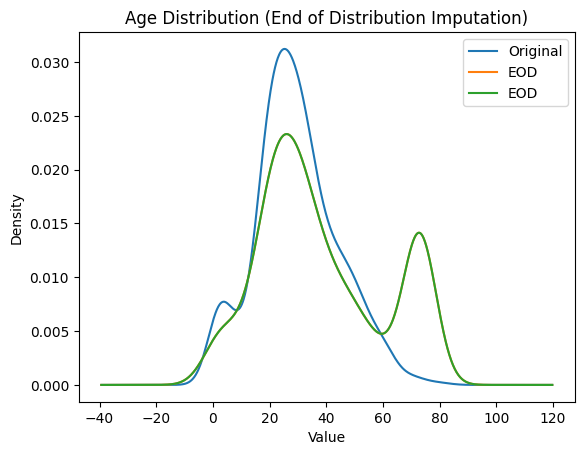

In [1177]:
plot_distribution(
    X_train['Age'],
    X_train_eod['Age_eod'],
    X_train_eod['Age_eod'],
    ['EOD', 'EOD'],
    "Age Distribution (End of Distribution Imputation)"
)

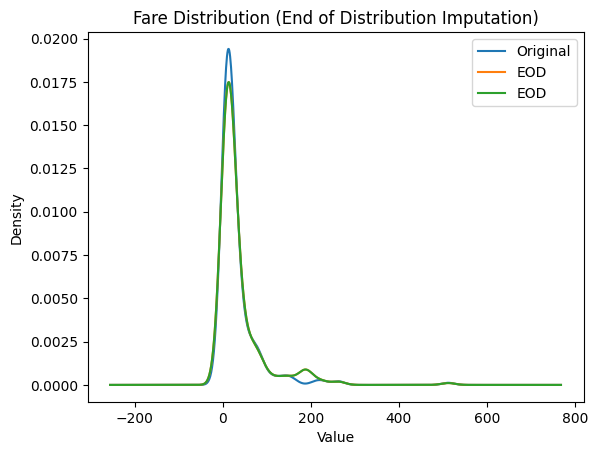

In [1178]:
plot_distribution(
    X_train['Fare'],
    X_train_eod['Fare_eod'],
    X_train_eod['Fare_eod'],
    ['EOD', 'EOD'],
    "Fare Distribution (End of Distribution Imputation)"
)

In [1179]:
mean_age=X_train['Age'].mean()
std_age=X_train['Age'].std()

mean_fare=X_train['Fare'].mean()
std_fare=X_train['Fare'].std()

extreme_value_age=mean_age+3*std_age
extreme_value_fare=mean_fare+3*std_fare

In [1180]:
imputer_age=SimpleImputer(strategy='constant', fill_value=extreme_value_age)
imputer_fare=SimpleImputer(strategy='constant', fill_value=extreme_value_fare)

In [1181]:
trf_eod=ColumnTransformer([
    ('imputer_age', imputer_age, ['Age']),
    ('imputer_fare', imputer_fare, ['Fare'])
], remainder='passthrough')

In [1182]:
trf_eod.fit(X_train)

X_train_eod_trans=trf_eod.transform(X_train)
X_test_eod_trans=trf_eod.transform(X_test)

X_train_eod_trans=pd.DataFrame(X_train_eod_trans, columns=['Age', 'Fare'], index=X_train.index)
X_test_eod_trans=pd.DataFrame(X_test_eod_trans, columns=['Age', 'Fare'], index=X_test.index)

In [1183]:
X_train_eod_trans.head()

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750


## 4. Categorical Imputation
* **Most Frequent Imputation:** Used when data is Missing Completely at Random (MCAR). We simply replace missing values with the mode (the most common category).
* **"Missing" Category Imputation:** Used when missingness isn't random. We treat the NaN itself as a brand new category called "Missing".

In [1184]:
df=pd.read_csv('Titanic-Dataset.csv')

In [1185]:
df=df[['Sex', 'Embarked', 'Survived']]

In [1186]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Survived']), df['Survived'], test_size=0.2, random_state=42)

In [1187]:
df.head()

,Sex,Embarked,Survived
0,male,S,0
1,female,C,1
2,female,S,1
3,NaN,S,1
4,male,S,0


In [1188]:
X_train.isnull().mean()*100

Sex          2.387640
Embarked    13.061798
dtype: float64

<Axes: xlabel='Sex'>

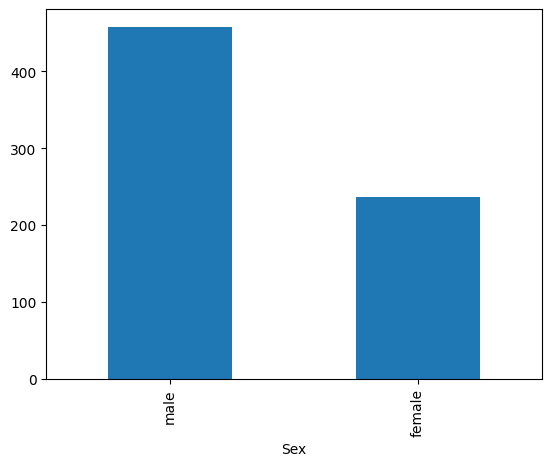

In [1189]:
X_train['Sex'].value_counts().plot(kind='bar')

In [1190]:
X_train['Sex'].mode()

0    male
Name: Sex, dtype: object

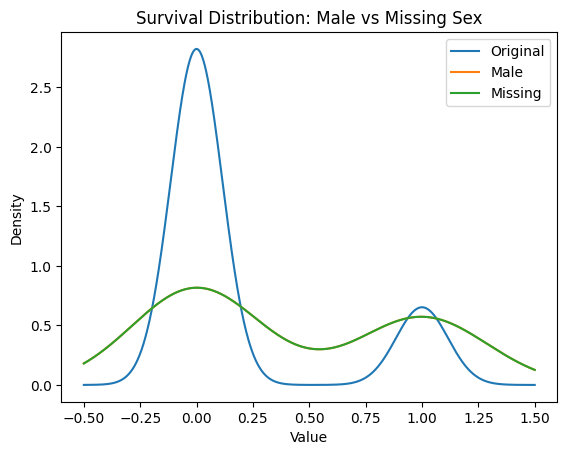

In [1191]:
plot_distribution(
    y_train[X_train['Sex']=='male'],
    y_train[X_train['Sex'].isnull()],
    y_train[X_train['Sex'].isnull()],  # dummy
    ['Male', 'Missing'],
    "Survival Distribution: Male vs Missing Sex"
)

In [1192]:
temp=y_train[X_train['Sex'] == 'male']

In [1193]:
X_train_cat=X_train.copy()

In [1194]:
X_train_cat['Sex'] = X_train_cat['Sex'].fillna('male')

<Axes: xlabel='Sex'>

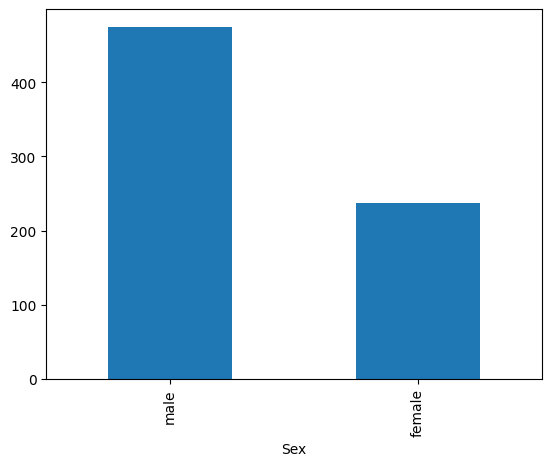

In [1195]:
X_train_cat['Sex'].value_counts().plot(kind='bar')

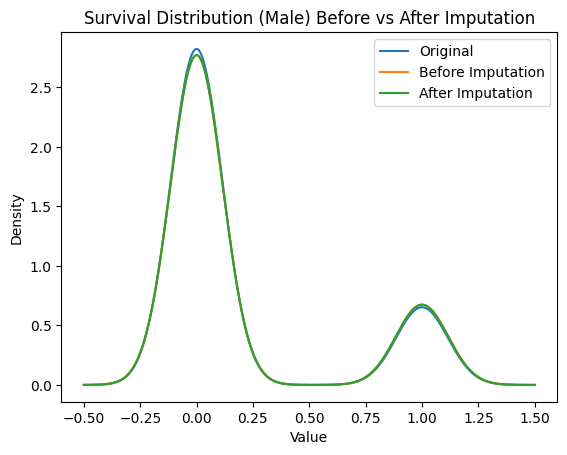

In [1196]:
plot_distribution(
    temp,
    y_train[X_train_cat['Sex'] == 'male'],
    y_train[X_train_cat['Sex'] == 'male'],  # dummy
    ['Before Imputation', 'After Imputation'],
    "Survival Distribution (Male) Before vs After Imputation"
)

<Axes: xlabel='Embarked'>

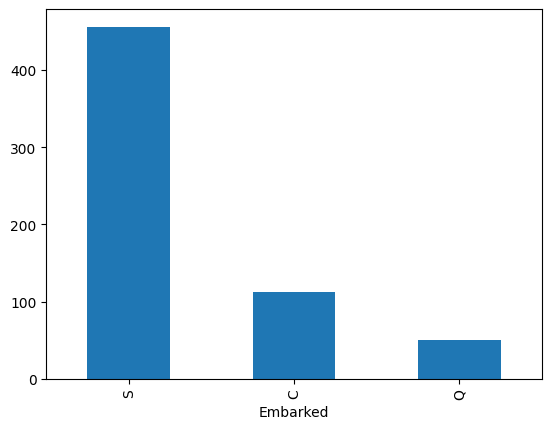

In [1197]:
X_train['Embarked'].value_counts().plot(kind='bar')

In [1198]:
imputer_freq=SimpleImputer(strategy='most_frequent')

In [1199]:
trf_freq = ColumnTransformer([
    ('imputer', imputer_freq, ['Sex', 'Embarked']),
], remainder='passthrough')

In [1200]:
trf_freq.fit(X_train)

X_train_trans=trf_freq.transform(X_train)
X_test_trans=trf_freq.transform(X_test)

X_train_trans=pd.DataFrame(X_train_trans, columns=['Sex', 'Embarked'], index=X_train.index)
X_test_trans=pd.DataFrame(X_test_trans, columns=['Sex', 'Embarked'], index=X_test.index)

In [1201]:
X_train_trans.head()

,Sex,Embarked
331,male,S
733,male,S
382,male,S
704,male,S
813,female,S


### Missing Category

In [1202]:
X_train_missing=X_train.copy()
X_test_missing=X_test.copy()

In [1203]:
imputer_missing=SimpleImputer(strategy='constant', fill_value='Missing')

In [1204]:
trf_missing = ColumnTransformer([
    ('imputer', imputer_missing, ['Sex', 'Embarked']),
], remainder='passthrough')

In [1205]:
trf_missing.fit(X_train_missing)

X_train_missing_trans=trf_missing.transform(X_train_missing)
X_test_missing_trans=trf_missing.transform(X_test_missing)

X_train_missing_trans=pd.DataFrame(X_train_missing_trans, columns=['Sex', 'Embarked'], index=X_train.index)
X_test_missing_trans=pd.DataFrame(X_test_missing_trans, columns=['Sex', 'Embarked'], index=X_test.index)

In [1206]:
X_train_missing_trans.head()

,Sex,Embarked
331,male,S
733,male,S
382,male,S
704,male,Missing
813,female,S


<Axes: xlabel='Sex'>

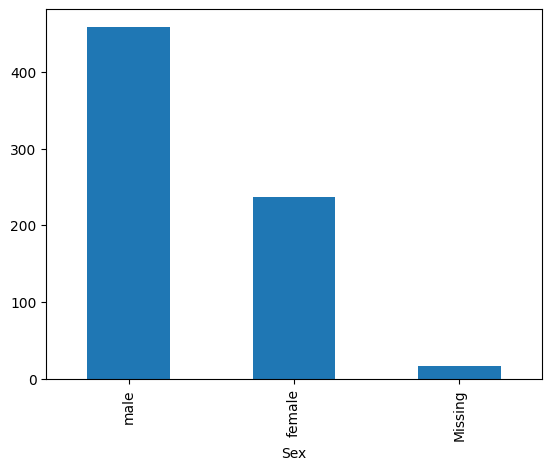

In [1207]:
X_train_missing_trans['Sex'].value_counts().plot(kind='bar')